# B4 — Cross-Fitted AIPW: Overall Private-vs-Public Effect

**Interpretation rule, stated up front and repeated at the end: this is a
selection-on-observables causal-style estimate, not randomized causality.**
It is only as credible as the assumption that the 8 confounders below
capture everything that jointly affects both facility choice and C-section
risk. It does not prove causation the way a randomized trial would.

**Not run here.** Written but not executed, per instruction — no commands
run, no model fit, no bootstrap performed while authoring this notebook.
Run it locally in VS Code.

**Confounder set — identical to the just-revised `06_propensity_overlap_diagnostics.ipynb`:**
`birth_order`, `twin_order`, `wealth_index`, `education_years`, `residence`,
`religion`, `social_group`, `state`. `maternal_age`, `bmi`, and
`health_insurance` remain excluded from the primary set for the same
documented reasons as in notebook 06 (age-at-interview vs. age-at-birth
ambiguity; unverified pre-exposure timing) — this notebook does not
re-litigate that decision, it inherits it.

**How survey weights and AIPW combine, stated precisely because it's easy
to get wrong:** the propensity term inside the AIPW pseudo-outcome
(`1/e_hat`, `1/(1-e_hat)`) handles **confounding adjustment**. The survey
weight (`sample_weight_normalized`) handles **sampling-design
representativeness**. These are conceptually different corrections and are
combined by applying the survey weight as an *outer* multiplier when
averaging the AIPW pseudo-outcomes across the sample — **not** by also
multiplying a separate stabilized IPW term into the pseudo-outcome itself,
which would double-count the propensity adjustment. This differs
deliberately from notebook 06's `combined_weight` (survey × stabilized IPW),
which was a *diagnostic* device for that notebook's balance checks, not the
formula used here.

**Bootstrap caveat, stated explicitly:** the cluster bootstrap below
resamples the *final AIPW averaging step* using the already-computed,
cross-fitted nuisance predictions — it does **not** refit the propensity
and outcome models inside each bootstrap replicate. Refitting per replicate
would be the more complete approach but is computationally prohibitive for
a notebook meant to run locally; the simplification is standard practice in
applied AIPW work, but it means the reported CI does not fully capture
uncertainty from nuisance-model estimation itself, only from the final
averaging step.

## 1. Imports, paths, constants

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")

OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METADATA_DIR = OUTPUTS_DIR / "metadata"
for d in (TABLES_DIR, FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_FOLDS = 5
CLIP_EPS = 1e-6          # numerical clipping so e_hat is strictly within (0, 1)
TRIM_LOWER = 0.05        # diagnostic extreme-propensity thresholds (reporting only, not applied by default)
TRIM_UPPER = 0.95
N_BOOTSTRAP = 500
BOOTSTRAP_SEED = 42
RUN_TRIMMED_SENSITIVITY = False  # optional: recompute RD/RR after excluding extreme-PS records
OUTCOME_MODEL_TYPE = "xgboost"   # "xgboost" or "logistic_regression" -- see Section 5

## 2. Load `df_model_v2` (read-only), restrict to public/private, assert integrity

In [2]:
df = pd.read_parquet(V2_PATH)  # read-only
n_loaded = len(df)

EXPECTED_ROW_COUNT = 201311
assert n_loaded == EXPECTED_ROW_COUNT, (
    f"df_model_v2 row count is {n_loaded}, expected {EXPECTED_ROW_COUNT}. Stop and investigate."
)

n_other = (df["facility_type"] == "other").sum()
analytic = df[df["facility_type"].isin(["public", "private"])].copy().reset_index(drop=True)

assert set(analytic["facility_type"].unique()) <= {"public", "private"}, \
    "Non public/private facility type leaked into the analytic sample."
print(f"Excluded 'other' facility records: {n_other}")
print(f"Analytic sample (public + private only): {len(analytic)} of {n_loaded}")

analytic["exposure"] = (analytic["facility_type"] == "private").astype(int)
assert analytic["exposure"].isna().sum() == 0, "Missing exposure values found."
assert analytic["csection"].isna().sum() == 0, "Missing outcome values found."
print("No missing exposure or outcome values.")
print(analytic["exposure"].value_counts().rename({0: "public", 1: "private"}))

Excluded 'other' facility records: 517
Analytic sample (public + private only): 200794 of 201311
No missing exposure or outcome values.
exposure
public     150299
private     50495
Name: count, dtype: int64


## 3. Confounder set (identical to notebook 06) and the forbidden-variable guard

In [3]:
numeric_confounders = ["birth_order", "wealth_index", "education_years"]
categorical_confounders = ["residence", "religion", "social_group", "twin_order", "state"]
confounder_cols = numeric_confounders + categorical_confounders

forbidden_as_confounder = {
    "anc_visits", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "first_anc_timing", "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy", "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "facility_type", "delivery_place_code",
    "bmi", "health_insurance", "maternal_age",
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
    "total_children_ever_born", "preceding_birth_interval", "age_at_first_birth",
    "district",
    "respondent_id", "birth_index", "cluster_number", "household_number", "respondent_line_number",
    "sample_weight", "sample_weight_normalized", "primary_sampling_unit",
    "sample_stratum_v022", "sample_stratum_v023",
    "csection",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
}

# --- Assertion: no forbidden/mediator variable in the confounder set ---
overlap = forbidden_as_confounder.intersection(set(confounder_cols))
assert not overlap, f"Forbidden/mediator variable found in confounder set: {overlap}"
print(f"Confounder set: {len(confounder_cols)} variables. No mediator/forbidden overlap confirmed.")
print("Note: 'exposure' is deliberately used as a FEATURE in the outcome model only (Section 5) -- "
      "it is never a confounder input to the propensity model.")

Confounder set: 8 variables. No mediator/forbidden overlap confirmed.
Note: 'exposure' is deliberately used as a FEATURE in the outcome model only (Section 5) -- it is never a confounder input to the propensity model.


## 4. Build analysis arrays and the cross-fitting split

5-fold `StratifiedGroupKFold`, stratified on exposure, grouped by
`respondent_id` — the same grouping discipline used everywhere else in this
project, so no respondent's records can appear in both the training and
held-out portions of any fold.

In [4]:
W = analytic[confounder_cols].copy()
for col in categorical_confounders:
    W[col] = W[col].astype("string").fillna("Missing").astype(str)

exposure = analytic["exposure"].to_numpy()
outcome = analytic["csection"].astype(int).to_numpy()
survey_weight = analytic["sample_weight_normalized"].to_numpy()
groups = analytic["respondent_id"].to_numpy()
psu = analytic["cluster_number"].to_numpy()
stratum = analytic["sample_stratum_v022"].to_numpy()

n_analytic = len(analytic)
assert len(W) == n_analytic, "Row count changed while building the confounder matrix."

splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_assignments = np.full(n_analytic, -1, dtype=int)
fold_indices = list(splitter.split(W, exposure, groups))

# --- Assertion: no fold leakage by respondent ---
for fold_id, (train_idx, test_idx) in enumerate(fold_indices):
    train_respondents = set(groups[train_idx])
    test_respondents = set(groups[test_idx])
    leak = train_respondents & test_respondents
    assert not leak, f"Fold {fold_id}: {len(leak)} respondents appear in both train and held-out portions."
    fold_assignments[test_idx] = fold_id

# --- Assertion: every row gets exactly one OOF fold assignment ---
assert (fold_assignments >= 0).all(), "Some rows were never assigned to a held-out fold."
covered = np.concatenate([test_idx for _, test_idx in fold_indices])
assert len(covered) == n_analytic and len(set(covered.tolist())) == n_analytic, \
    "Row coverage across folds is not an exact one-to-one partition."
print(f"Cross-fitting: {N_FOLDS} folds, grouped by respondent_id. No fold leakage. Every row covered exactly once.")

Cross-fitting: 5 folds, grouped by respondent_id. No fold leakage. Every row covered exactly once.


## 5. Nuisance model definitions

**Propensity model:** Logistic Regression on the confounder set only,
survey-weighted (same specification as notebook 06's primary model).

**Outcome model:** an S-learner — one model trained on confounders +
`exposure` as a feature, survey-weighted, then queried twice per held-out
record (once with `exposure` forced to 1, once forced to 0) to obtain
`mu1_hat` and `mu0_hat`. `OUTCOME_MODEL_TYPE` controls whether this is
XGBoost (default, fixed and deliberately modest hyperparameters — no
tuning search was run for this nuisance model) or Logistic Regression.

In [5]:
propensity_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), numeric_confounders),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_confounders),
])


def make_propensity_pipeline():
    return Pipeline([
        ("pre", propensity_preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])


outcome_numeric = numeric_confounders + ["exposure"]

if OUTCOME_MODEL_TYPE == "xgboost":
    outcome_preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="median", add_indicator=True), outcome_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_confounders),
    ])

    def make_outcome_pipeline():
        return Pipeline([
            ("pre", outcome_preprocessor),
            ("clf", XGBClassifier(
                objective="binary:logistic", eval_metric="logloss",
                random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
                n_estimators=200, max_depth=4, learning_rate=0.05,
            )),
        ])
elif OUTCOME_MODEL_TYPE == "logistic_regression":
    outcome_preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), outcome_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_confounders),
    ])

    def make_outcome_pipeline():
        return Pipeline([
            ("pre", outcome_preprocessor),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ])
else:
    raise ValueError(f"Unrecognized OUTCOME_MODEL_TYPE: {OUTCOME_MODEL_TYPE}")

print(f"Outcome model type: {OUTCOME_MODEL_TYPE}")

Outcome model type: xgboost


## 6. Cross-fitting loop — generate out-of-fold `e_hat`, `mu1_hat`, `mu0_hat`

For each fold: fit both nuisance models on the training portion only
(survey-weighted), predict on the held-out portion only. No model ever
predicts on data it was trained on.

In [6]:
e_hat = np.full(n_analytic, np.nan)
mu1_hat = np.full(n_analytic, np.nan)
mu0_hat = np.full(n_analytic, np.nan)

W_with_exposure = W.copy()
W_with_exposure["exposure"] = exposure

for fold_id, (train_idx, test_idx) in enumerate(fold_indices):
    print(f"Fold {fold_id}: train n={len(train_idx)}, held-out n={len(test_idx)}")

    # --- Propensity model: confounders only, survey-weighted ---
    prop_pipeline = make_propensity_pipeline()
    prop_pipeline.fit(
        W.iloc[train_idx], exposure[train_idx],
        clf__sample_weight=survey_weight[train_idx],
    )
    e_hat[test_idx] = prop_pipeline.predict_proba(W.iloc[test_idx])[:, 1]

    # --- Outcome model: confounders + exposure, survey-weighted ---
    outcome_pipeline = make_outcome_pipeline()
    outcome_pipeline.fit(
        W_with_exposure.iloc[train_idx], outcome[train_idx],
        clf__sample_weight=survey_weight[train_idx],
    )

    held_out_W = W_with_exposure.iloc[test_idx].copy()

    held_out_as_treated = held_out_W.copy()
    held_out_as_treated["exposure"] = 1
    mu1_hat[test_idx] = outcome_pipeline.predict_proba(held_out_as_treated)[:, 1]

    held_out_as_control = held_out_W.copy()
    held_out_as_control["exposure"] = 0
    mu0_hat[test_idx] = outcome_pipeline.predict_proba(held_out_as_control)[:, 1]

print("Cross-fitting complete.")

Fold 0: train n=160636, held-out n=40158
Fold 1: train n=160636, held-out n=40158
Fold 2: train n=160636, held-out n=40158
Fold 3: train n=160634, held-out n=40160
Fold 4: train n=160634, held-out n=40160
Cross-fitting complete.


## 7. Clip propensity, and run the required nuisance-prediction assertions

In [7]:
e_hat_clipped = np.clip(e_hat, CLIP_EPS, 1 - CLIP_EPS)

# --- Assertion: no NaN nuisance predictions ---
assert not np.isnan(e_hat_clipped).any(), "NaN found in e_hat."
assert not np.isnan(mu1_hat).any(), "NaN found in mu1_hat."
assert not np.isnan(mu0_hat).any(), "NaN found in mu0_hat."

# --- Assertion: propensity strictly within clipping bounds ---
assert (e_hat_clipped > 0).all() and (e_hat_clipped < 1).all(), \
    "Clipped propensity values are not strictly within (0, 1)."
assert (e_hat_clipped >= CLIP_EPS).all() and (e_hat_clipped <= 1 - CLIP_EPS).all(), \
    "Clipped propensity values fall outside the declared clipping bounds."

n_clipped = int(((e_hat <= CLIP_EPS) | (e_hat >= 1 - CLIP_EPS)).sum())
print(f"No NaN nuisance predictions. Records requiring numerical clipping: {n_clipped} of {n_analytic}.")

No NaN nuisance predictions. Records requiring numerical clipping: 0 of 200794.


## 8. Diagnostics — propensity range, extreme-PS counts, positivity/common support

In [8]:
extreme_ps = (e_hat_clipped < TRIM_LOWER) | (e_hat_clipped > TRIM_UPPER)

diagnostic_rows = []
for label, mask in [("overall", np.ones(n_analytic, dtype=bool)),
                     ("private", exposure == 1), ("public", exposure == 0)]:
    diagnostic_rows.append({
        "group": label,
        "n": int(mask.sum()),
        "propensity_min": float(e_hat_clipped[mask].min()),
        "propensity_max": float(e_hat_clipped[mask].max()),
        "propensity_mean": float(e_hat_clipped[mask].mean()),
        "n_extreme_lt_0.05_or_gt_0.95": int(extreme_ps[mask].sum()),
        "pct_extreme": round(float(extreme_ps[mask].mean()) * 100, 2),
    })
positivity_summary = pd.DataFrame(diagnostic_rows)
print(positivity_summary)

# --- Nuisance-prediction sanity checks ---
raw_weighted_mean_private = np.average(outcome[exposure == 1], weights=survey_weight[exposure == 1])
raw_weighted_mean_public = np.average(outcome[exposure == 0], weights=survey_weight[exposure == 0])
oof_mean_mu1_among_treated = np.average(mu1_hat[exposure == 1], weights=survey_weight[exposure == 1])
oof_mean_mu0_among_control = np.average(mu0_hat[exposure == 0], weights=survey_weight[exposure == 0])
oof_mean_e_hat = np.average(e_hat_clipped, weights=survey_weight)
raw_weighted_exposure_prevalence = np.average(exposure, weights=survey_weight)

print(f"\nSanity check -- raw weighted P(C-section | private): {raw_weighted_mean_private:.4f} "
      f"vs OOF mean mu1_hat among treated: {oof_mean_mu1_among_treated:.4f}")
print(f"Sanity check -- raw weighted P(C-section | public): {raw_weighted_mean_public:.4f} "
      f"vs OOF mean mu0_hat among control: {oof_mean_mu0_among_control:.4f}")
print(f"Sanity check -- raw weighted P(private): {raw_weighted_exposure_prevalence:.4f} "
      f"vs OOF weighted mean e_hat: {oof_mean_e_hat:.4f}")
print("Large divergences here would indicate a poorly calibrated nuisance model -- investigate before trusting the AIPW estimate below.")

     group       n  propensity_min  propensity_max  propensity_mean  \
0  overall  200794        0.004916        0.971420         0.259406   
1  private   50495        0.005513        0.971420         0.408720   
2   public  150299        0.004916        0.916025         0.209242   

   n_extreme_lt_0.05_or_gt_0.95  pct_extreme  
0                         17501         8.72  
1                           474         0.94  
2                         17027        11.33  

Sanity check -- raw weighted P(C-section | private): 0.4737 vs OOF mean mu1_hat among treated: 0.4697
Sanity check -- raw weighted P(C-section | public): 0.1431 vs OOF mean mu0_hat among control: 0.1449
Sanity check -- raw weighted P(private): 0.3011 vs OOF weighted mean e_hat: 0.3011
Large divergences here would indicate a poorly calibrated nuisance model -- investigate before trusting the AIPW estimate below.


## 9. AIPW estimate — survey-weighted risk under private and public

In [9]:
def aipw_psi(y, a, e, mu1, mu0):
    psi1 = mu1 + (a / e) * (y - mu1)
    psi0 = mu0 + ((1 - a) / (1 - e)) * (y - mu0)
    return psi1, psi0


def aipw_point_estimate(y, a, e, mu1, mu0, weights):
    psi1, psi0 = aipw_psi(y, a, e, mu1, mu0)
    r1 = np.average(psi1, weights=weights)
    r0 = np.average(psi0, weights=weights)
    return r1, r0, r1 - r0, r1 / r0


r1_hat, r0_hat, risk_difference, risk_ratio = aipw_point_estimate(
    outcome, exposure, e_hat_clipped, mu1_hat, mu0_hat, survey_weight,
)

print(f"AIPW survey-weighted risk under private: {r1_hat * 100:.2f}%")
print(f"AIPW survey-weighted risk under public: {r0_hat * 100:.2f}%")
print(f"Risk Difference (private - public): {risk_difference * 100:.2f} percentage points")
print(f"Risk Ratio (private / public): {risk_ratio:.3f}")

AIPW survey-weighted risk under private: 44.96%
AIPW survey-weighted risk under public: 16.49%
Risk Difference (private - public): 28.47 percentage points
Risk Ratio (private / public): 2.726


### 9a. Optional trimmed sensitivity (off by default)

Recomputes the same point estimate after excluding records with
`e_hat` outside `[TRIM_LOWER, TRIM_UPPER]`, using the same already-computed
nuisance predictions -- a positivity sensitivity check, not a different
primary estimate.

In [10]:
if RUN_TRIMMED_SENSITIVITY:
    keep = ~extreme_ps
    r1_trim, r0_trim, rd_trim, rr_trim = aipw_point_estimate(
        outcome[keep], exposure[keep], e_hat_clipped[keep], mu1_hat[keep], mu0_hat[keep], survey_weight[keep],
    )
    print(f"Trimmed sensitivity -- N retained: {keep.sum()} of {n_analytic}")
    print(f"Trimmed RD: {rd_trim * 100:.2f} pts | Trimmed RR: {rr_trim:.3f}")
else:
    rd_trim = rr_trim = None
    print("RUN_TRIMMED_SENSITIVITY is False -- skipping.")

RUN_TRIMMED_SENSITIVITY is False -- skipping.


## 10. PSU-cluster bootstrap for confidence intervals

Resamples PSUs (`cluster_number`) with replacement, **within**
`sample_stratum_v022` strata -- the same approach used in the B3
standardization notebook. Uses the fixed, already-computed nuisance
predictions for every replicate (see the caveat in the intro cell).

In [11]:
def resample_indices_within_strata(psu_ids, stratum_ids, rng):
    row_positions = np.arange(len(psu_ids))
    out = []
    for s in np.unique(stratum_ids):
        stratum_mask = stratum_ids == s
        psus_in_stratum = np.unique(psu_ids[stratum_mask])
        n_psu = len(psus_in_stratum)
        drawn_psus = rng.choice(psus_in_stratum, size=n_psu, replace=True)
        for drawn_psu in drawn_psus:
            out.append(row_positions[stratum_mask & (psu_ids == drawn_psu)])
    return np.concatenate(out)


rng = np.random.RandomState(BOOTSTRAP_SEED)
rd_reps = np.empty(N_BOOTSTRAP)
rr_reps = np.empty(N_BOOTSTRAP)

for b in range(N_BOOTSTRAP):
    idx = resample_indices_within_strata(psu, stratum, rng)
    _, _, rd_b, rr_b = aipw_point_estimate(
        outcome[idx], exposure[idx], e_hat_clipped[idx], mu1_hat[idx], mu0_hat[idx], survey_weight[idx],
    )
    rd_reps[b] = rd_b
    rr_reps[b] = rr_b

rd_ci = (np.percentile(rd_reps, 2.5), np.percentile(rd_reps, 97.5))
rr_ci = (np.percentile(rr_reps, 2.5), np.percentile(rr_reps, 97.5))

print(f"Risk Difference: {risk_difference * 100:.2f} pts, 95% CI [{rd_ci[0] * 100:.2f}, {rd_ci[1] * 100:.2f}]")
print(f"Risk Ratio: {risk_ratio:.3f}, 95% CI [{rr_ci[0]:.3f}, {rr_ci[1]:.3f}]")

Risk Difference: 28.47 pts, 95% CI [27.67, 29.24]
Risk Ratio: 2.726, 95% CI [2.657, 2.803]


## 11. Save row-level nuisance predictions, summary, and bootstrap CSVs

In [12]:
row_level = pd.DataFrame({
    "respondent_id": analytic["respondent_id"].to_numpy(),
    "facility_type": analytic["facility_type"].to_numpy(),
    "exposure": exposure,
    "csection": outcome,
    "sample_weight_normalized": survey_weight,
    "cluster_number": psu,
    "sample_stratum_v022": stratum,
    "fold": fold_assignments,
    "e_hat_raw": e_hat,
    "e_hat_clipped": e_hat_clipped,
    "mu1_hat": mu1_hat,
    "mu0_hat": mu0_hat,
    "extreme_propensity": extreme_ps,
})
row_level.to_csv(TABLES_DIR / "b4_aipw_row_level_nuisance.csv", index=False)
print(f"Saved row-level nuisance predictions: {row_level.shape}")

Saved row-level nuisance predictions: (200794, 13)


In [13]:
summary_row = {
    "r1_hat_private_risk_pct": r1_hat * 100,
    "r0_hat_public_risk_pct": r0_hat * 100,
    "risk_difference_pct": risk_difference * 100,
    "risk_difference_ci_low_pct": rd_ci[0] * 100,
    "risk_difference_ci_high_pct": rd_ci[1] * 100,
    "risk_ratio": risk_ratio,
    "risk_ratio_ci_low": rr_ci[0],
    "risk_ratio_ci_high": rr_ci[1],
    "n_analytic": n_analytic,
    "n_private": int((exposure == 1).sum()),
    "n_public": int((exposure == 0).sum()),
    "n_extreme_propensity": int(extreme_ps.sum()),
    "trimmed_sensitivity_rd_pct": (rd_trim * 100) if rd_trim is not None else np.nan,
    "trimmed_sensitivity_rr": rr_trim if rr_trim is not None else np.nan,
}
overall_summary = pd.DataFrame([summary_row])
overall_summary.to_csv(TABLES_DIR / "b4_aipw_overall_summary.csv", index=False)

bootstrap_results = pd.DataFrame({
    "replicate": np.arange(N_BOOTSTRAP),
    "risk_difference_pct": rd_reps * 100,
    "risk_ratio": rr_reps,
})
bootstrap_results.to_csv(TABLES_DIR / "b4_aipw_bootstrap_results.csv", index=False)

positivity_summary.to_csv(TABLES_DIR / "b4_aipw_positivity_summary.csv", index=False)

print("Saved: b4_aipw_overall_summary.csv, b4_aipw_bootstrap_results.csv, b4_aipw_positivity_summary.csv")
overall_summary

Saved: b4_aipw_overall_summary.csv, b4_aipw_bootstrap_results.csv, b4_aipw_positivity_summary.csv


,r1_hat_private_risk_pct,r0_hat_public_risk_pct,risk_difference_pct,risk_difference_ci_low_pct,risk_difference_ci_high_pct,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,n_analytic,n_private,n_public,n_extreme_propensity,trimmed_sensitivity_rd_pct,trimmed_sensitivity_rr
0,44.9644,16.494602,28.469798,27.671957,29.244259,2.726007,2.656604,2.803453,200794,50495,150299,17501,NaN,NaN


## 12. Bootstrap distribution figure

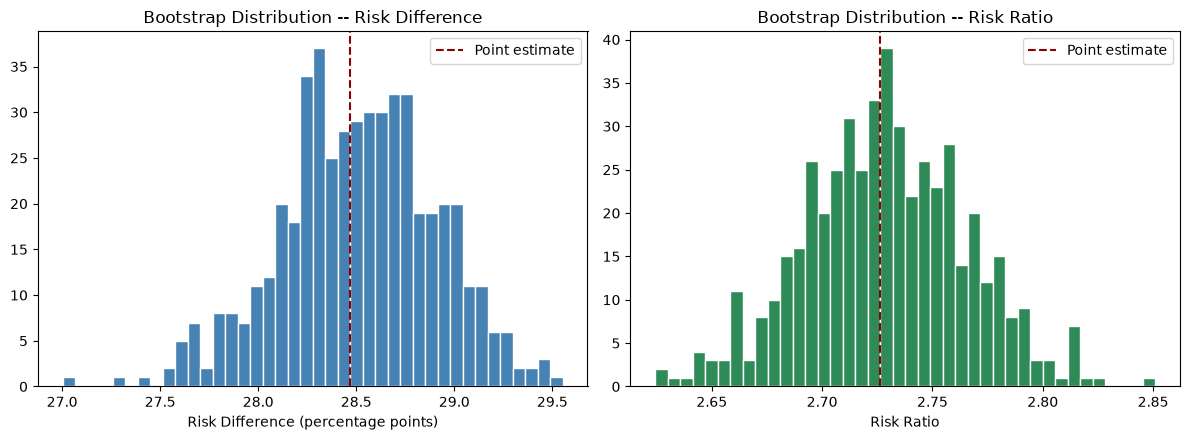

Saved: ..\..\outputs\figures\b4_aipw_bootstrap_distributions.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(rd_reps * 100, bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(risk_difference * 100, color="darkred", linestyle="--", label="Point estimate")
axes[0].set_xlabel("Risk Difference (percentage points)")
axes[0].set_title("Bootstrap Distribution -- Risk Difference")
axes[0].legend()

axes[1].hist(rr_reps, bins=40, color="seagreen", edgecolor="white")
axes[1].axvline(risk_ratio, color="darkred", linestyle="--", label="Point estimate")
axes[1].set_xlabel("Risk Ratio")
axes[1].set_title("Bootstrap Distribution -- Risk Ratio")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "b4_aipw_bootstrap_distributions.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b4_aipw_bootstrap_distributions.png")

## 13. Save metadata

In [15]:
metadata = {
    "random_state": RANDOM_STATE,
    "population": {"n_total_v2": n_loaded, "n_excluded_other": int(n_other), "n_analytic_sample": n_analytic},
    "exposure": {"private": 1, "public": 0},
    "confounder_set": confounder_cols,
    "cross_fitting": {
        "method": "StratifiedGroupKFold, stratified on exposure, grouped by respondent_id",
        "n_folds": N_FOLDS,
    },
    "nuisance_models": {
        "propensity": "LogisticRegression(max_iter=1000, random_state=42), survey-weighted via sample_weight_normalized",
        "outcome": f"{OUTCOME_MODEL_TYPE} S-learner (confounders + exposure as a feature), survey-weighted via sample_weight_normalized, fixed hyperparameters, no tuning on outcome",
    },
    "clipping": {"method": "hard clip", "epsilon": CLIP_EPS},
    "extreme_propensity_thresholds": {"lower": TRIM_LOWER, "upper": TRIM_UPPER},
    "weighting_combination": (
        "Survey weight (sample_weight_normalized) is applied as an OUTER multiplier when averaging "
        "AIPW pseudo-outcomes across the sample. It is NOT multiplied into the pseudo-outcome itself "
        "alongside the propensity terms (1/e_hat, 1/(1-e_hat)), which would double-count the "
        "confounding adjustment. This differs from notebook 06's diagnostic combined_weight."
    ),
    "bootstrap": {
        "method": "PSU-cluster bootstrap, resampled with replacement within sample_stratum_v022 strata",
        "n_replicates": N_BOOTSTRAP,
        "seed": BOOTSTRAP_SEED,
        "ci_method": "percentile (2.5 / 97.5)",
        "caveat": "Nuisance predictions are treated as fixed/plugged-in for every replicate; nuisance models are not refit per replicate.",
    },
    "trimmed_sensitivity_run": RUN_TRIMMED_SENSITIVITY,
    "interpretation_rule": (
        "Selection-on-observables causal-style estimate under consistency, positivity, and conditional "
        "exchangeability given the stated confounder set. NOT randomized causality. Credible only to the "
        "extent the confounder set is sufficient -- several plausible confounders (maternal_age, bmi, "
        "health_insurance, pregnancy complications) are excluded from this primary specification, "
        "documented in notebook 06."
    ),
}

with open(METADATA_DIR / "b4_aipw_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "b4_aipw_metadata.json")

Saved: ..\..\outputs\metadata\b4_aipw_metadata.json
